In [1]:
import pandas as pd
import numpy as np
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
import os

# Ensure required directories exist
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../results/figures', exist_ok=True)
os.makedirs('../results/metrics', exist_ok=True)
os.makedirs('../models', exist_ok=True)

In [5]:
# Download required NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print("MENTAL HEALTH SENTIMENT ANALYSIS - DATA PREPROCESSING")

MENTAL HEALTH SENTIMENT ANALYSIS - DATA PREPROCESSING


# 1. LOAD DATA

In [30]:
print("\nLoading data")

df = pd.read_csv('../data/processed/data_with_stats.csv')
print(f"Loaded {len(df)} samples")

# Define columns
text_col = 'statement'
label_col = 'status'

original_sample_count = len(df)


Loading data
Loaded 50311 samples


# 2. TEXT CLEANING FUNCTIONS

In [39]:
print("\nDefining text cleaning functions")

def clean_text(text):
    
    # Convert to string and lowercase
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove extra whitespace
    text = ' '.join(text.split())
    
    return text

def remove_stopwords(text):
    stop_words = set(stopwords.words('english'))
    # Keep negation words as they're important for sentiment
    negation_words = {'no', 'not', 'nor', 'neither', 'never', 'none', 
                     'nobody', 'nothing', 'nowhere', 'hardly', 'barely'}
    stop_words = stop_words - negation_words
    
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)

def lemmatize_text(text):
    lemmatizer = WordNetLemmatizer()
    words = text.split()
    lemmatized_words = [lemmatizer.lemmatize(word) for word in words]
    return ' '.join(lemmatized_words)

print(" Text cleaning functions defined")


Defining text cleaning functions
 Text cleaning functions defined


# 3. APPLY PREPROCESSING

In [45]:
print("\n Applying preprocessing pipeline")

# Show examples before preprocessing
print("\n Sample text BEFORE preprocessing:")
sample_text = df[text_col].iloc[0]
print(f"  Original: {sample_text}")

# Apply cleaning pipeline
print("\n  Applying cleaning steps")
df['cleaned_text'] = df[text_col].apply(clean_text)
print("   Basic cleaning done")

df['cleaned_text'] = df['cleaned_text'].apply(remove_stopwords)
print("   Stopwords removed")

df['cleaned_text'] = df['cleaned_text'].apply(lemmatize_text)
print("   Lemmatization done")

# Show example after preprocessing
print(f"\n  Cleaned: {df['cleaned_text'].iloc[0]}")

# Remove empty texts after cleaning
empty_mask = df['cleaned_text'].str.strip() == ''
print(f"\n Removing {empty_mask.sum()} empty texts after cleaning")
df = df[~empty_mask].reset_index(drop=True)



 Applying preprocessing pipeline

 Sample text BEFORE preprocessing:
  Original: oh my gosh

  Applying cleaning steps
   Basic cleaning done
   Stopwords removed
   Lemmatization done

  Cleaned: oh gosh

 Removing 0 empty texts after cleaning


In [53]:
# show first 3 cleaned texts
print("\n First 3 cleaned texts:")
print(df['cleaned_text'].head(3).to_list())


 First 3 cleaned texts:
['oh gosh', 'trouble sleeping confused mind restless heart tune', 'wrong back dear forward doubt stay restless restless place']


# 4. ANALYZE CLEANED TEXT


Analyzing cleaned text

 Cleaned text statistics:
  Average words: 53.95
  Min words: 1
  Max words: 3780

✓ Saved: results/figures/04_preprocessing_comparison.png


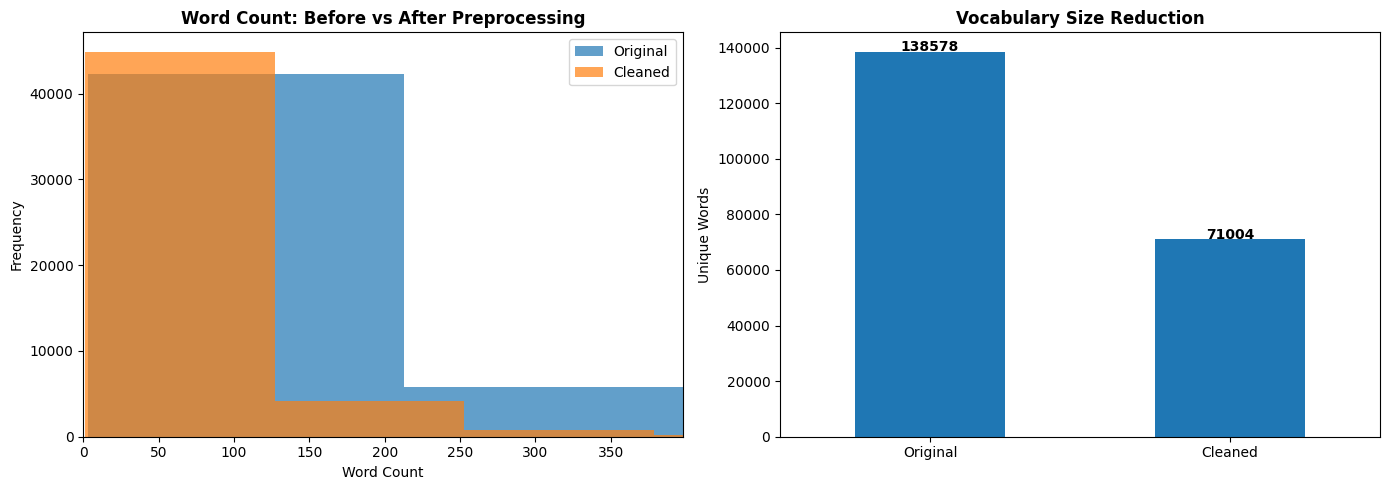


 Vocabulary reduction: 138578 → 71004 (48.8% reduction)


In [56]:
print("\nAnalyzing cleaned text")

# Word count after cleaning
df['cleaned_word_count'] = df['cleaned_text'].apply(lambda x: len(x.split()))

print(f"\n Cleaned text statistics:")
print(f"  Average words: {df['cleaned_word_count'].mean():.2f}")
print(f"  Min words: {df['cleaned_word_count'].min()}")
print(f"  Max words: {df['cleaned_word_count'].max()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram: Original vs Cleaned word count
axes[0].hist(df['word_count'], bins=30, alpha=0.7, label='Original')
axes[0].hist(df['cleaned_word_count'], bins=30, alpha=0.7, label='Cleaned')
axes[0].set_title('Word Count: Before vs After Preprocessing', fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].set_xlim(0, df['word_count'].quantile(0.95))  # ignore extreme outliers

original_vocab = set(' '.join(df[text_col].astype(str)).lower().split())
cleaned_vocab = set(' '.join(df['cleaned_text']).split())

vocab_data = pd.DataFrame({
    'Type': ['Original', 'Cleaned'],
    'Vocabulary Size': [len(original_vocab), len(cleaned_vocab)]
})

vocab_data.plot(x='Type', y='Vocabulary Size', kind='bar', ax=axes[1], legend=False)
axes[1].set_title('Vocabulary Size Reduction', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Unique Words')
axes[1].tick_params(axis='x', rotation=0)

for i, v in enumerate(vocab_data['Vocabulary Size']):
    axes[1].text(i, v + 100, str(v), ha='center', fontweight='bold')


import os
os.makedirs('../results/figures', exist_ok=True)

plt.tight_layout()
plt.savefig('../results/figures/04_preprocessing_comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: results/figures/04_preprocessing_comparison.png")
plt.show()

print(f"\n Vocabulary reduction: {len(original_vocab)} → {len(cleaned_vocab)} "
      f"({(1 - len(cleaned_vocab)/len(original_vocab))*100:.1f}% reduction)")

# 5. ENCODE LABELS

In [61]:
print("\nEncoding labels")

# Create label encoder
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df[label_col])

print(f"\n Label mapping:")
for idx, label in enumerate(label_encoder.classes_):
    count = (df['label'] == idx).sum()
    print(f"  {label} → {idx} ({count} samples)")

import os
os.makedirs('../models', exist_ok=True)
import pickle
with open('../models/label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)
print("\n Label encoder saved to: models/label_encoder.pkl")


Encoding labels

 Label mapping:
  Anxiety → 0 (3605 samples)
  Bipolar → 1 (2501 samples)
  Depression → 2 (15064 samples)
  Normal → 3 (15269 samples)
  Personality disorder → 4 (895 samples)
  Stress → 5 (2293 samples)
  Suicidal → 6 (10630 samples)

 Label encoder saved to: models/label_encoder.pkl


# 6. TRAIN-VAL-TEST SPLIT

In [64]:
print("\n Splitting data into train/val/test sets")

from sklearn.model_selection import train_test_split
import os

X = df['cleaned_text']
y = df['label']

# First split: train+val vs test (15% test)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Second split
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
)

print(f"\n Split sizes:")
print(f"  Train: {len(X_train)} ({len(X_train)/len(df)*100:.1f}%)")
print(f"  Val:   {len(X_val)} ({len(X_val)/len(df)*100:.1f}%)")
print(f"  Test:  {len(X_test)} ({len(X_test)/len(df)*100:.1f}%)")

print(f"\n Class distribution:")
for split_name, y_split in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    print(f"\n  {split_name}:")
    for label in label_encoder.classes_:
        idx = label_encoder.transform([label])[0]
        count = (y_split == idx).sum()
        pct = count / len(y_split) * 100
        print(f"    {label}: {count} ({pct:.1f}%)")


 Splitting data into train/val/test sets

 Split sizes:
  Train: 35199 (70.0%)
  Val:   7519 (15.0%)
  Test:  7539 (15.0%)

 Class distribution:

  Train:
    Anxiety: 2525 (7.2%)
    Bipolar: 1752 (5.0%)
    Depression: 10550 (30.0%)
    Normal: 10694 (30.4%)
    Personality disorder: 627 (1.8%)
    Stress: 1606 (4.6%)
    Suicidal: 7445 (21.2%)

  Val:
    Anxiety: 539 (7.2%)
    Bipolar: 374 (5.0%)
    Depression: 2254 (30.0%)
    Normal: 2285 (30.4%)
    Personality disorder: 134 (1.8%)
    Stress: 343 (4.6%)
    Suicidal: 1590 (21.1%)

  Test:
    Anxiety: 541 (7.2%)
    Bipolar: 375 (5.0%)
    Depression: 2260 (30.0%)
    Normal: 2290 (30.4%)
    Personality disorder: 134 (1.8%)
    Stress: 344 (4.6%)
    Suicidal: 1595 (21.2%)


**Visualize splits**


 Saved: results/figures/05_data_splits.png


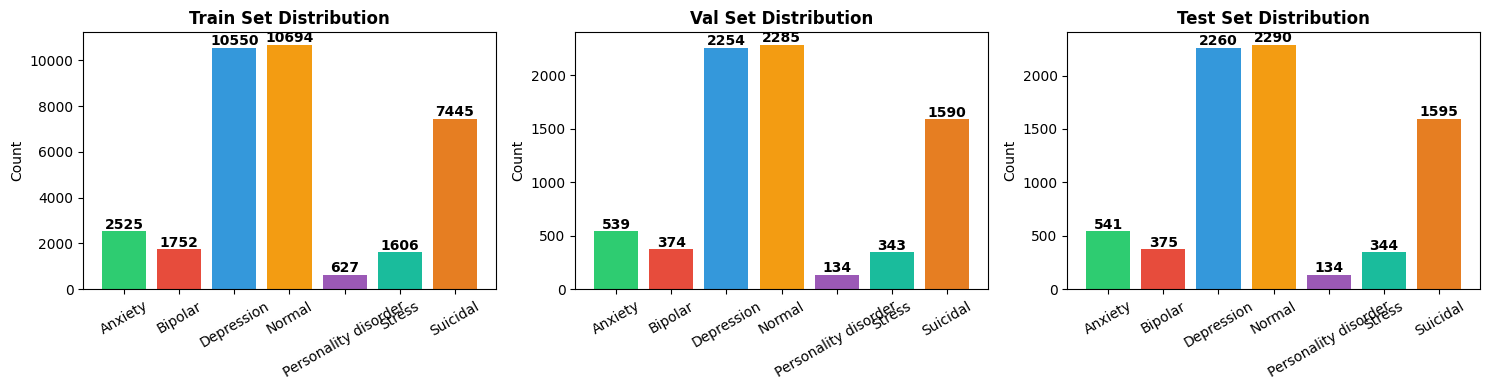

In [69]:
os.makedirs('../results/figures', exist_ok=True)  

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22']

for idx, (split_name, y_split) in enumerate([('Train', y_train), ('Val', y_val), ('Test', y_test)]):
    counts = pd.Series(y_split).value_counts().sort_index()
    labels = [label_encoder.classes_[i] for i in counts.index]
    
    axes[idx].bar(labels, counts.values, color=colors[:len(counts)])
    axes[idx].set_title(f'{split_name} Set Distribution', fontweight='bold')
    axes[idx].set_ylabel('Count')
    axes[idx].tick_params(axis='x', rotation=30)
    
    for i, v in enumerate(counts.values):
        axes[idx].text(i, v + max(counts.values)*0.01, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/figures/05_data_splits.png', dpi=300, bbox_inches='tight')
print("\n Saved: results/figures/05_data_splits.png")
plt.show()

# 7. SAVE PROCESSED DATA

In [78]:
print("\nSaving processed datasets")

import os
import json

# Ensure directories exist
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../results/metrics', exist_ok=True)

# Create DataFrames
train_df = pd.DataFrame({'text': X_train.values, 'label': y_train.values})
val_df   = pd.DataFrame({'text': X_val.values, 'label': y_val.values})
test_df  = pd.DataFrame({'text': X_test.values, 'label': y_test.values})


# Save CSVs
train_df.to_csv('../data/processed/train.csv', index=False)
val_df.to_csv('../data/processed/val.csv', index=False)
test_df.to_csv('../data/processed/test.csv', index=False)

print(" Saved processed datasets:")
print("  - ../data/processed/train.csv")
print("  - ../data/processed/val.csv")
print("  - ../data/processed/test.csv")

# Save complete processed data
df[['cleaned_text', 'label', label_col]].to_csv(
    '../data/processed/processed_data.csv', index=False
)
print("  - ../data/processed/processed_data.csv")


preprocessing_summary = {
    'original_samples': len(df),
    'train_samples': len(train_df),
    'val_samples': len(val_df),
    'test_samples': len(test_df),
    'original_vocab_size': len(original_vocab),
    'cleaned_vocab_size': len(cleaned_vocab),
    'label_mapping': {label: int(idx) for idx, label in enumerate(label_encoder.classes_)}
}

with open('../results/metrics/preprocessing_summary.json', 'w') as f:
    json.dump(preprocessing_summary, f, indent=4)
print("  - ../results/metrics/preprocessing_summary.json")


Saving processed datasets
 Saved processed datasets:
  - ../data/processed/train.csv
  - ../data/processed/val.csv
  - ../data/processed/test.csv
  - ../data/processed/processed_data.csv
  - ../results/metrics/preprocessing_summary.json
